File: bursting/cell89basal.abf | sweeps: 30 | total length: 645.00 s
     Burst_Number  Start_Time_s  End_Time_s         Type
0               1       76.5200     77.4671  Square Wave
1               2      104.7433    107.4776  Square Wave
2               3      191.0791    193.4927  Square Wave
3               4      207.6007    212.0541  Square Wave
4               5      322.6933    322.8075  Square Wave
..            ...           ...         ...          ...
272           273      632.1943    634.1843    Parabolic
273           274      634.5038    634.7590    Parabolic
274           275      638.2392    638.3164    Parabolic
275           276      638.6217    639.7094    Parabolic
276           277      642.4200    642.5522    Parabolic

[277 rows x 4 columns]


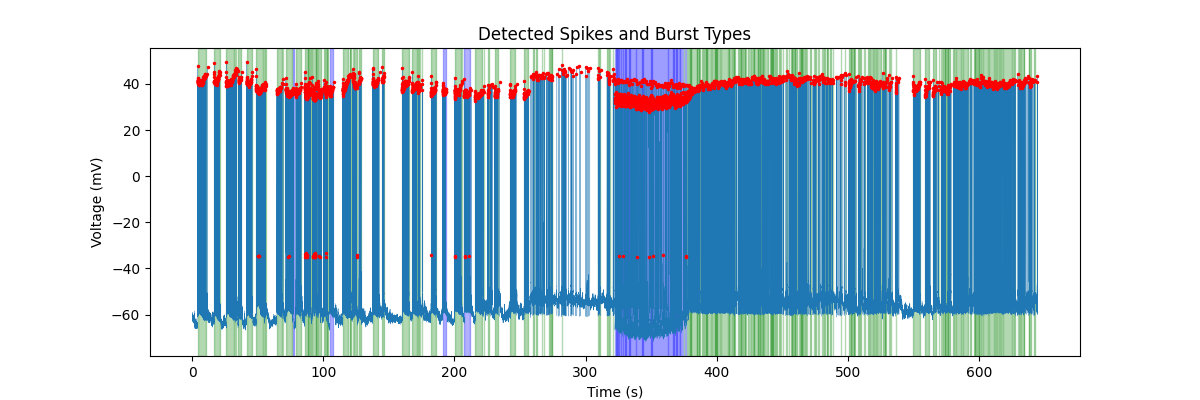

In [ ]:

# SPIKE AND BURST DETECTION

# This script detects action potentials ("spikes") and groups them into
# "bursts" using simple time-based criteria. It then classifies bursts
# by their shape and saves the results to a CSV file.

import pyabf                      # Library for reading Axon Binary Files (.abf)
import numpy as np                # Numerical operations (efficient arrays, math)
import pandas as pd               # For tabular data and CSV output
import matplotlib.pyplot as plt   # For plotting and visualization
from scipy.signal import find_peaks  # Used to detect spikes (local maxima)
%matplotlib widget              


# 1. Load electrophysiology data (.abf)

file_path = "bursting/cell89basal.abf"  # Path to the ABF file
abf = pyabf.ABF(file_path)              # Load the file into an ABF object
# Each ABF file may contain several "sweeps" (repeated recordings)


# 2. Concatenate all sweeps into one long signal

# abf.setSweep(i) loads sweep i into memory and updates abf.sweepY (voltage data)
# The expression “abf.setSweep(i) or abf.sweepY” works because setSweep(i)
# returns None (evaluates as False), so Python returns abf.sweepY instead.
# np.concatenate merges all sweeps into one continuous vector.
signal = np.concatenate([abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)])

# Compute the time axis:
dt = 1.0 / abf.dataRate            # Sampling interval (seconds per sample)
time = np.arange(len(signal)) * dt # Time vector from 0 to total recording length

# Print some file info for confirmation
print(f"File: {file_path} | sweeps: {abf.sweepCount} | total length: {time[-1]:.2f} s")


# 3. Detect spikes (action potentials)

threshold = -35  # mV  voltage threshold above which peaks are considered spikes
# find_peaks searches for local maxima whose amplitude ≥ threshold
spike_indices, _ = find_peaks(signal, height=threshold)
# spike_indices: array of sample positions where spikes were found
# The underscore "_" ignores additional info (like peak heights)
spike_times = time[spike_indices]  # Convert indices to time (in seconds)
# Now we have a list of spike times representing each detected action potential.


# 4. Detect bursts (groups of spikes close in time)

isi = np.diff(spike_times)         # Inter-spike intervals: time gaps between consecutive spikes
burst_threshold = 0.3  # s         # Maximum ISI to still belong to the same burst

bursts = []                        # Will store tuples (burst_start_time, burst_end_time)
current_burst = [spike_times[0]]   # Start the first burst with the first spike

# Iterate through all ISIs and group spikes into bursts
for i in range(1, len(isi)):
    if isi[i-1] < burst_threshold:
        # If this spike is close enough to the previous one,
        # it belongs to the same burst
        current_burst.append(spike_times[i])
    else:
        # If there's a longer gap, the previous burst ends here.
        if len(current_burst) > 1:
            # Only store bursts that have more than one spike
            bursts.append((current_burst[0], current_burst[-1]))
        # Start a new burst
        current_burst = [spike_times[i]]

# After looping, check if the last burst still needs to be saved
if len(current_burst) > 1:
    bursts.append((current_burst[0], current_burst[-1]))

# bursts now contains a list of (start_time, end_time) pairs in seconds.

# 5. Classify bursts by their waveform shape

# We'll classify each burst as:
# - "Square Wave"    if it maintains depolarization above the baseline
# - "Parabolic"      if it dips below baseline
# - "Other"          if it doesn't fit either pattern

square_wave_bursts = []   # Container for “Square Wave” bursts
parabolic_bursts = []     # Container for “Parabolic” bursts
other_bursts = []         # Container for any unclassified bursts

for i, (burst_start, burst_end) in enumerate(bursts):
    # Create a boolean mask selecting samples inside the burst window
    burst_mask = (time >= burst_start) & (time <= burst_end)

    # Find the minimum voltage inside this burst
    burst_min = np.min(signal[burst_mask])

    # Compute the average voltage between bursts (baseline)
    prev_mean = np.mean(signal[(time > bursts[i-1][1]) & (time < burst_start)]) if i > 0 else np.nan
    next_mean = np.mean(signal[(time > burst_end) & (time < bursts[i+1][0])]) if i < len(bursts)-1 else np.nan
    inter_mean = np.nanmean([prev_mean, next_mean])  # Average baseline (ignore NaNs)

    # Compare the minimum burst value to the baseline to classify it
    if burst_min > inter_mean:
        # If the burst minimum is higher than baseline → depolarized plateau
        square_wave_bursts.append((burst_start, burst_end))
    elif burst_min < inter_mean:
        # If the burst minimum is lower than baseline → downward parabola shape
        parabolic_bursts.append((burst_start, burst_end))
    else:
        # Otherwise, doesn’t fit either category
        other_bursts.append((burst_start, burst_end))


# 6. Save the burst information to a CSV file
burst_list = []  # List of all bursts (for DataFrame creation)

# Add square-wave bursts first
for idx, (start, end) in enumerate(square_wave_bursts):
    burst_list.append([idx+1, start, end, "Square Wave"])

# Then parabolic bursts, continuing numbering
for idx, (start, end) in enumerate(parabolic_bursts):
    burst_list.append([idx+1+len(square_wave_bursts), start, end, "Parabolic"])

# Finally, other bursts
for idx, (start, end) in enumerate(other_bursts):
    burst_list.append([idx+1+len(square_wave_bursts)+len(parabolic_bursts), start, end, "Other"])

# Create a pandas DataFrame with labeled columns
df_bursts = pd.DataFrame(burst_list, columns=["Burst_Number", "Start_Time_s", "End_Time_s", "Type"])

# Save as CSV file (no index column)
df_bursts.to_csv("burst_info_cell89.csv", index=False)
print(df_bursts)  # Display the summary table


# 7. Plot the full signal, detected spikes, and bursts

plt.figure(figsize=(12,4))  # Create a wide figure for clarity

# Plot the continuous voltage trace (thin gray line)
plt.plot(time, signal, lw=0.2)

# Plot detected spikes as small red dots
plt.plot(spike_times, signal[spike_indices], 'r.', markersize=3)

# Highlight bursts by shading regions with different colors
for start, end in square_wave_bursts:
    plt.axvspan(start, end, color='blue', alpha=0.3)   # Blue = Square Wave
for start, end in parabolic_bursts:
    plt.axvspan(start, end, color='green', alpha=0.3)  # Green = Parabolic
for start, end in other_bursts:
    plt.axvspan(start, end, color='orange', alpha=0.3) # Orange = Other

# Label axes and add title
plt.xlabel("Time (s)")                      # X-axis: time in seconds
plt.ylabel("Voltage (mV)")                  # Y-axis: membrane potential
plt.title("Detected Spikes and Burst Types")# Descriptive title

# Display the interactive figure
plt.show()

278 bursts detected
   Burst_Number  Start_Time_s  End_Time_s       Type
0             1        4.1492     10.4632  Parabolic
1             2       16.7984     21.0475  Parabolic
2             3       25.9975     31.7546  Parabolic
3             4       32.2976     32.6686  Parabolic
4             5       33.2434     33.6903  Parabolic
5             6       35.2539     37.2636  Parabolic
6             7       41.4399     45.3242  Parabolic
7             8       48.8635     53.6932  Parabolic
8             9       54.3833     55.0212  Parabolic
9            10       55.5536     56.1263  Parabolic


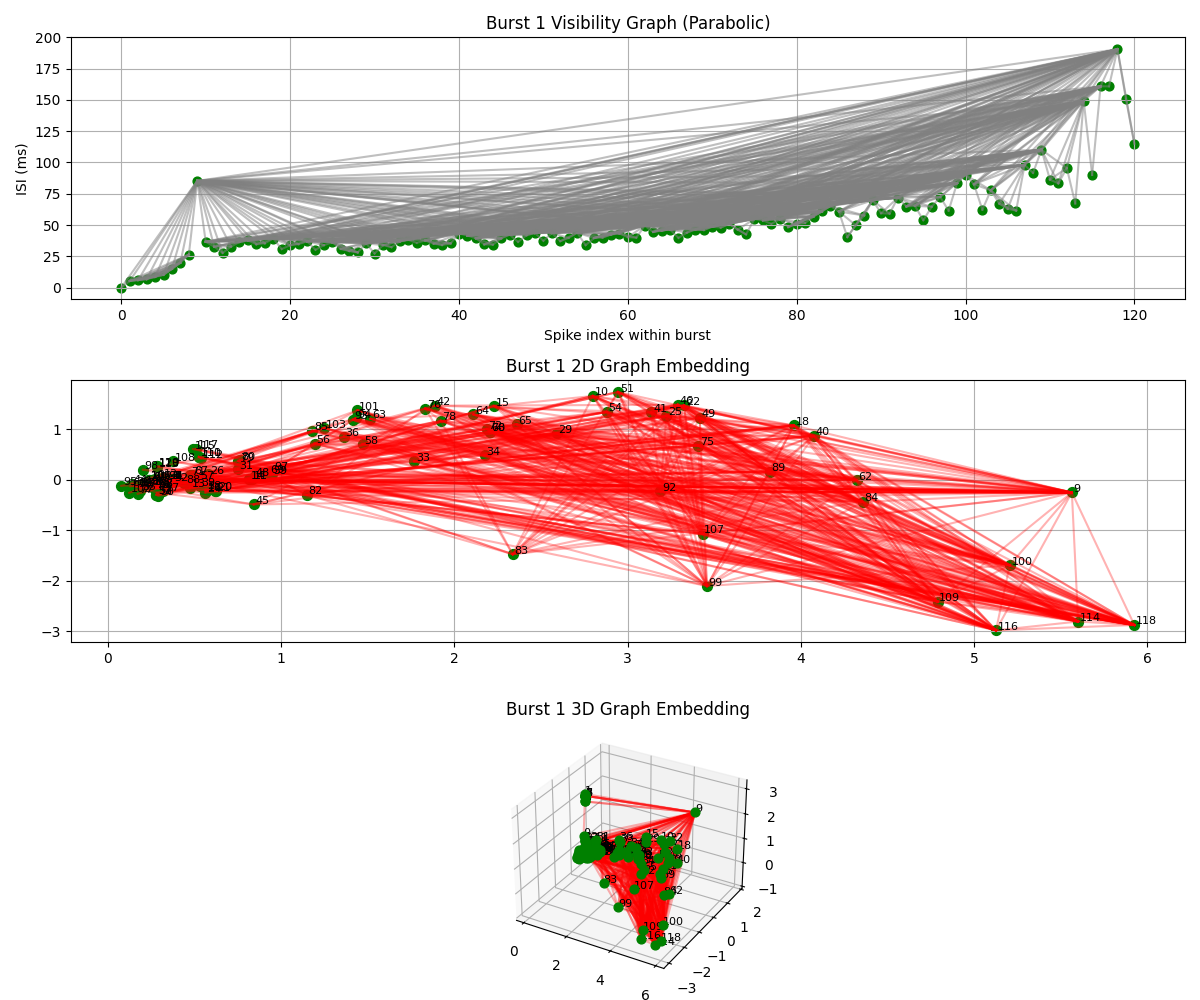

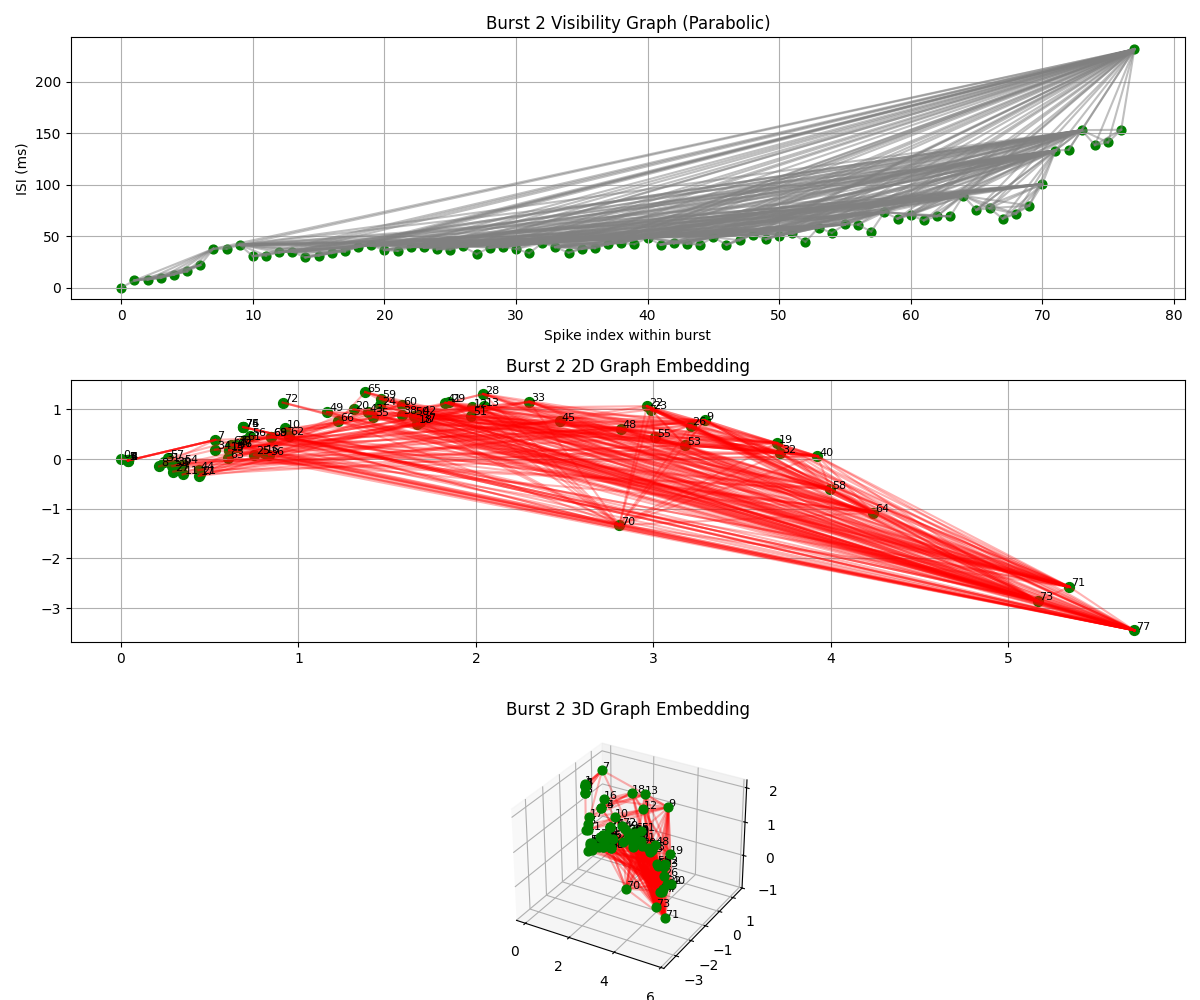

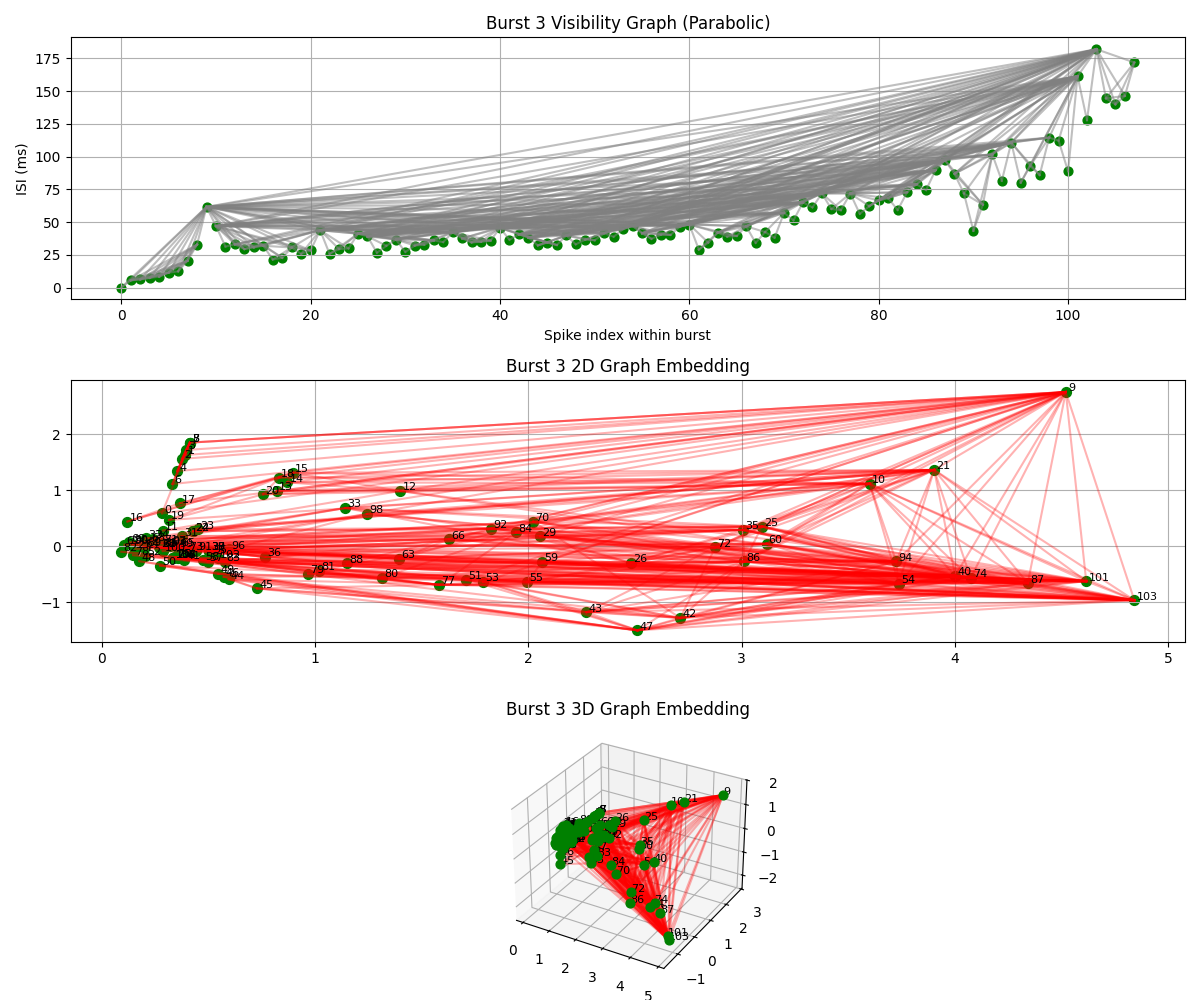

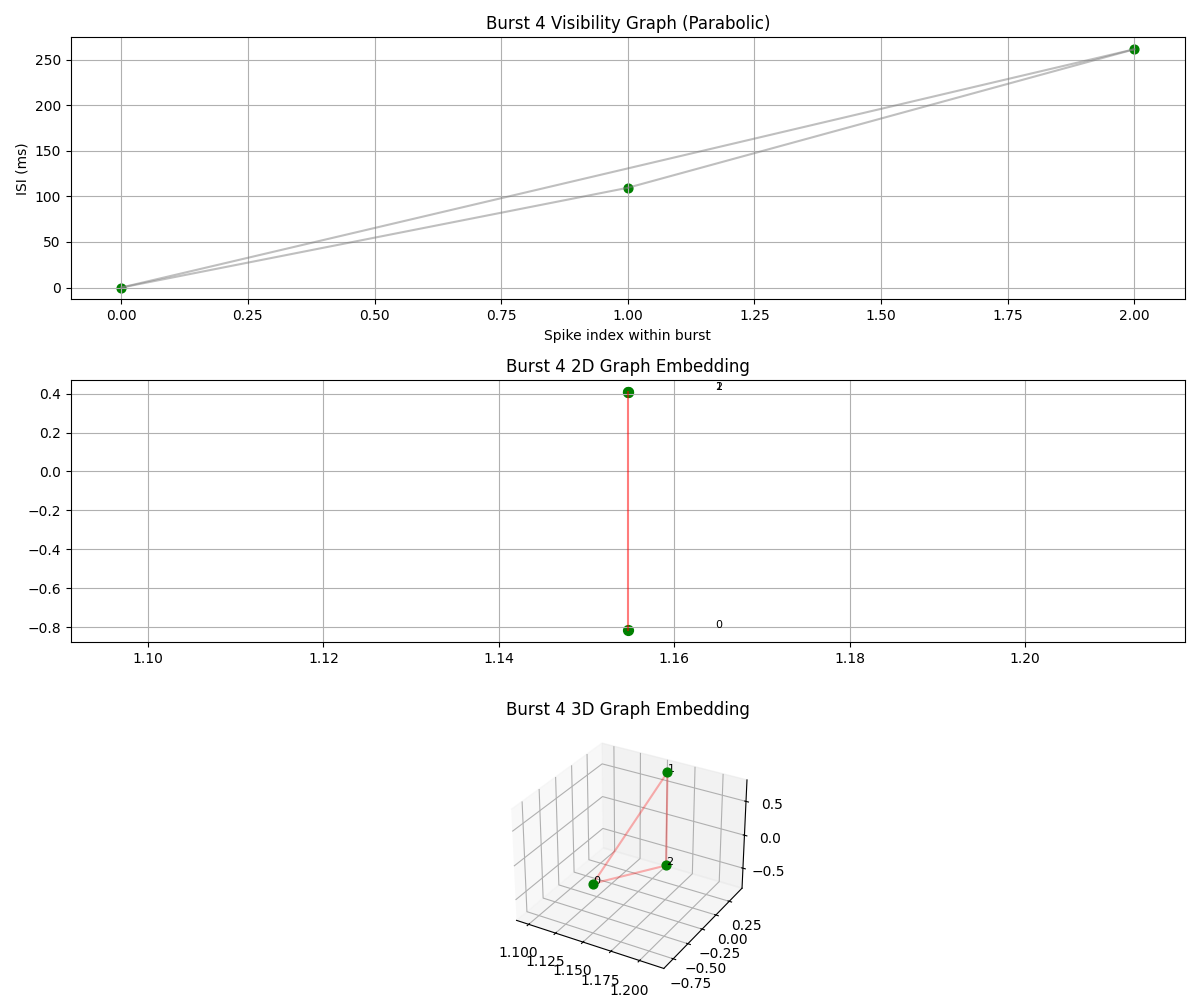

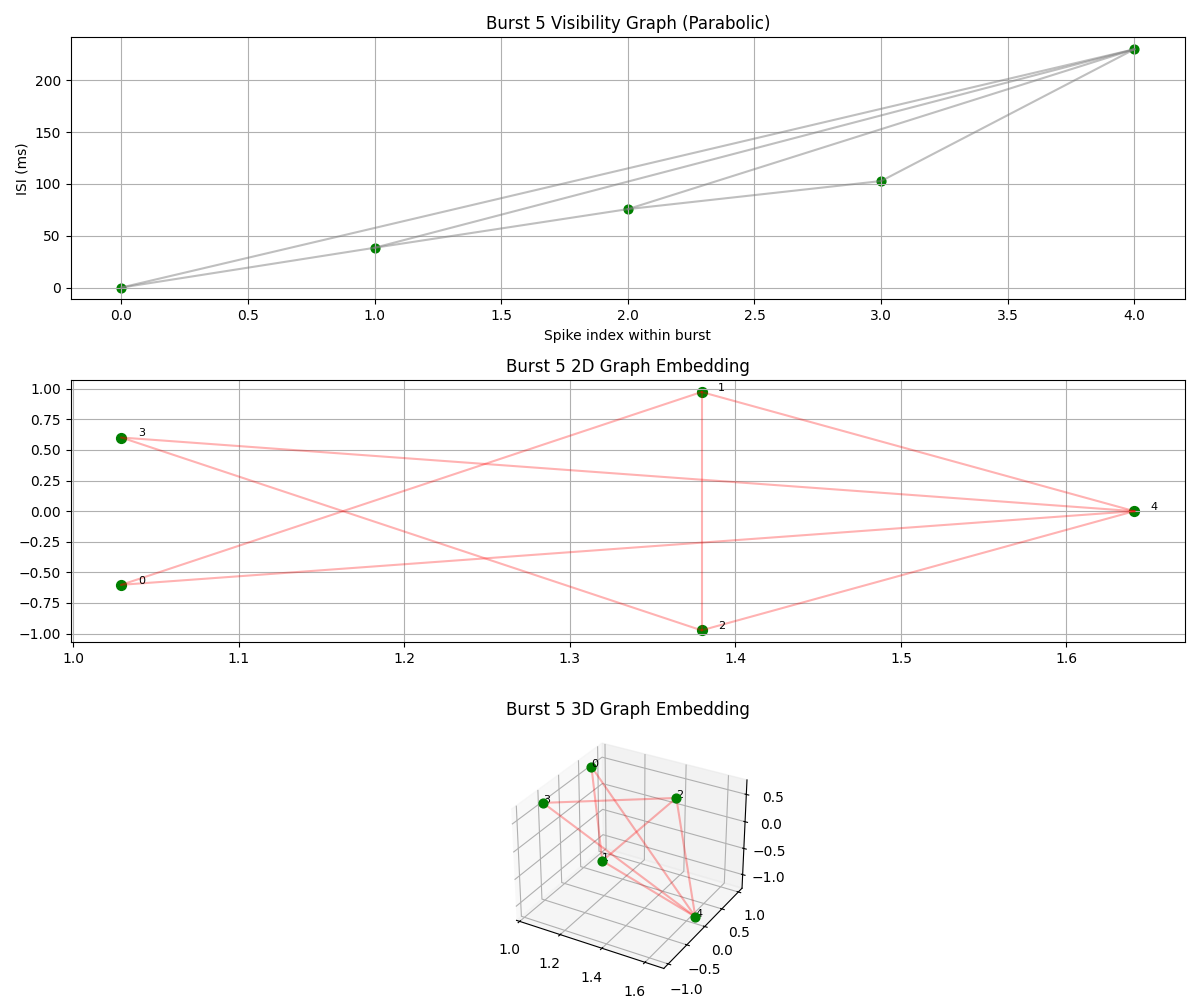

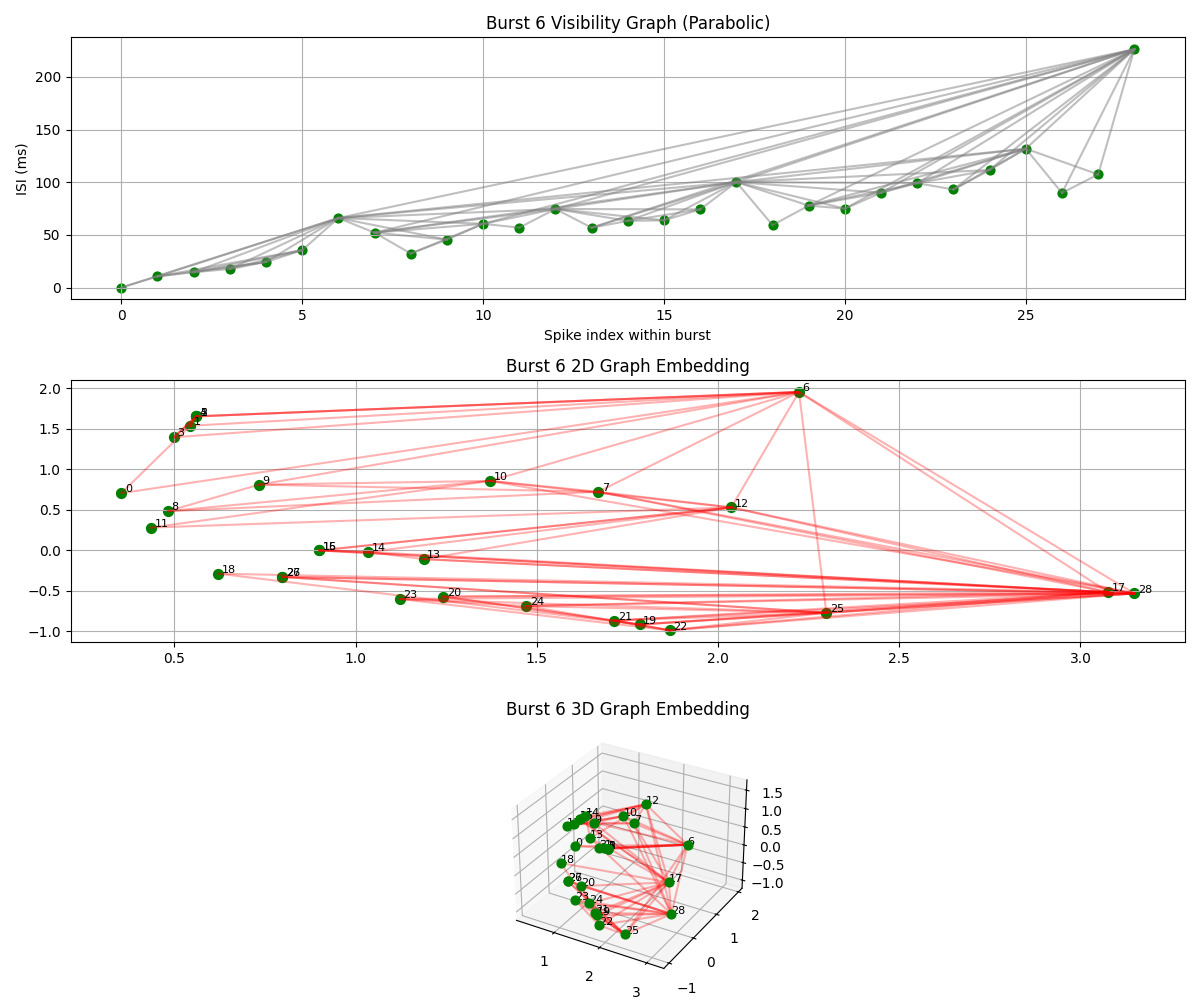

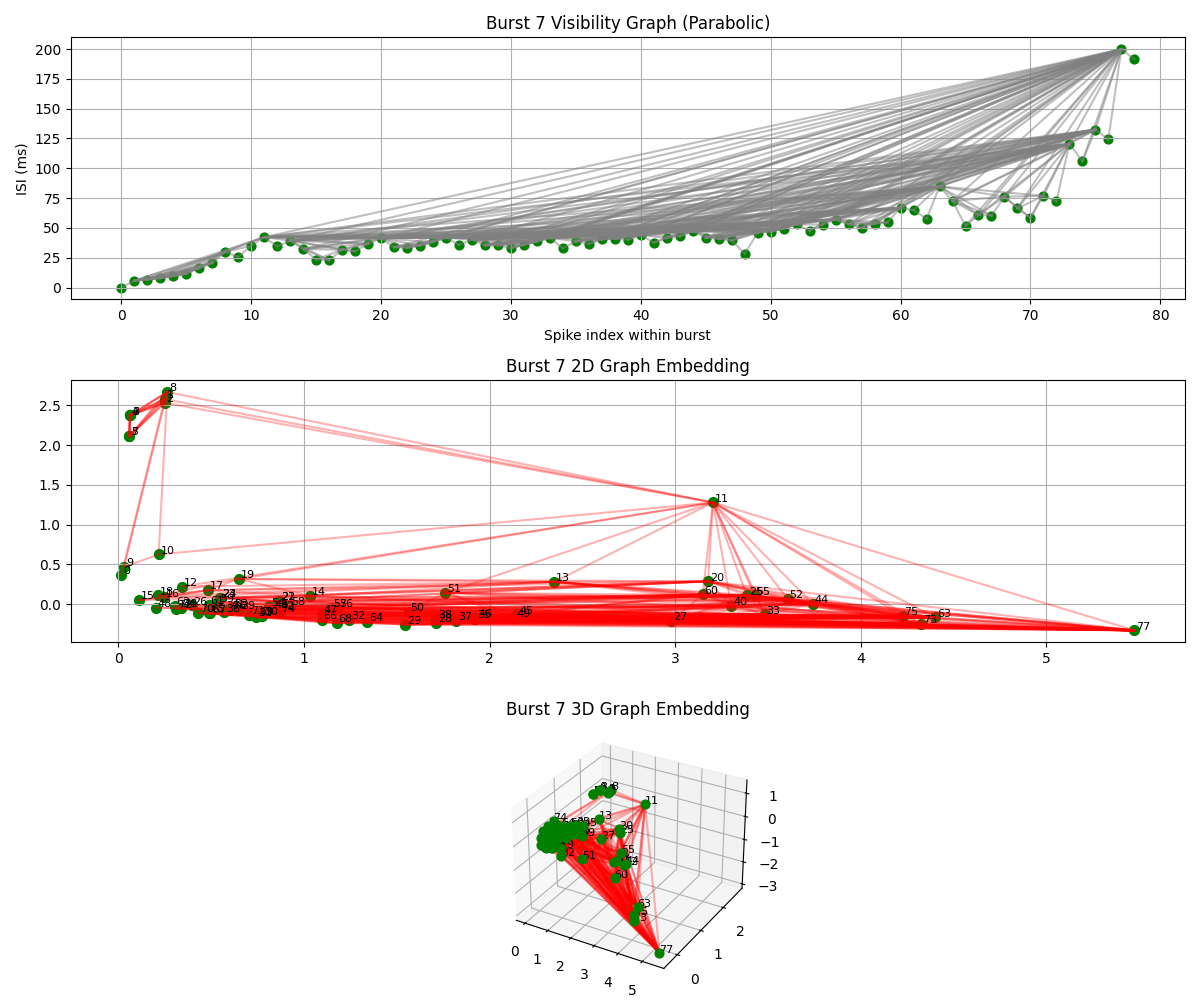

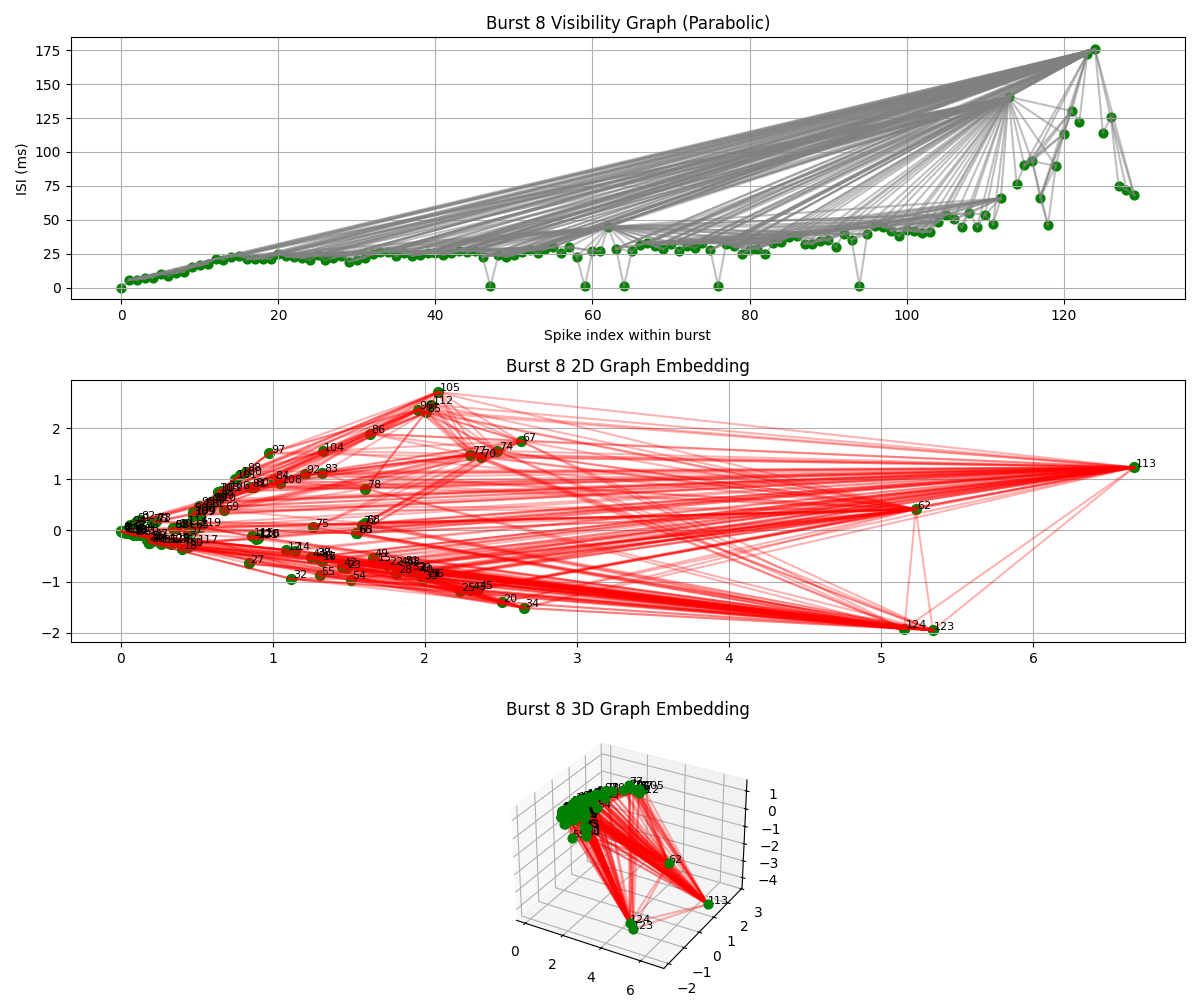

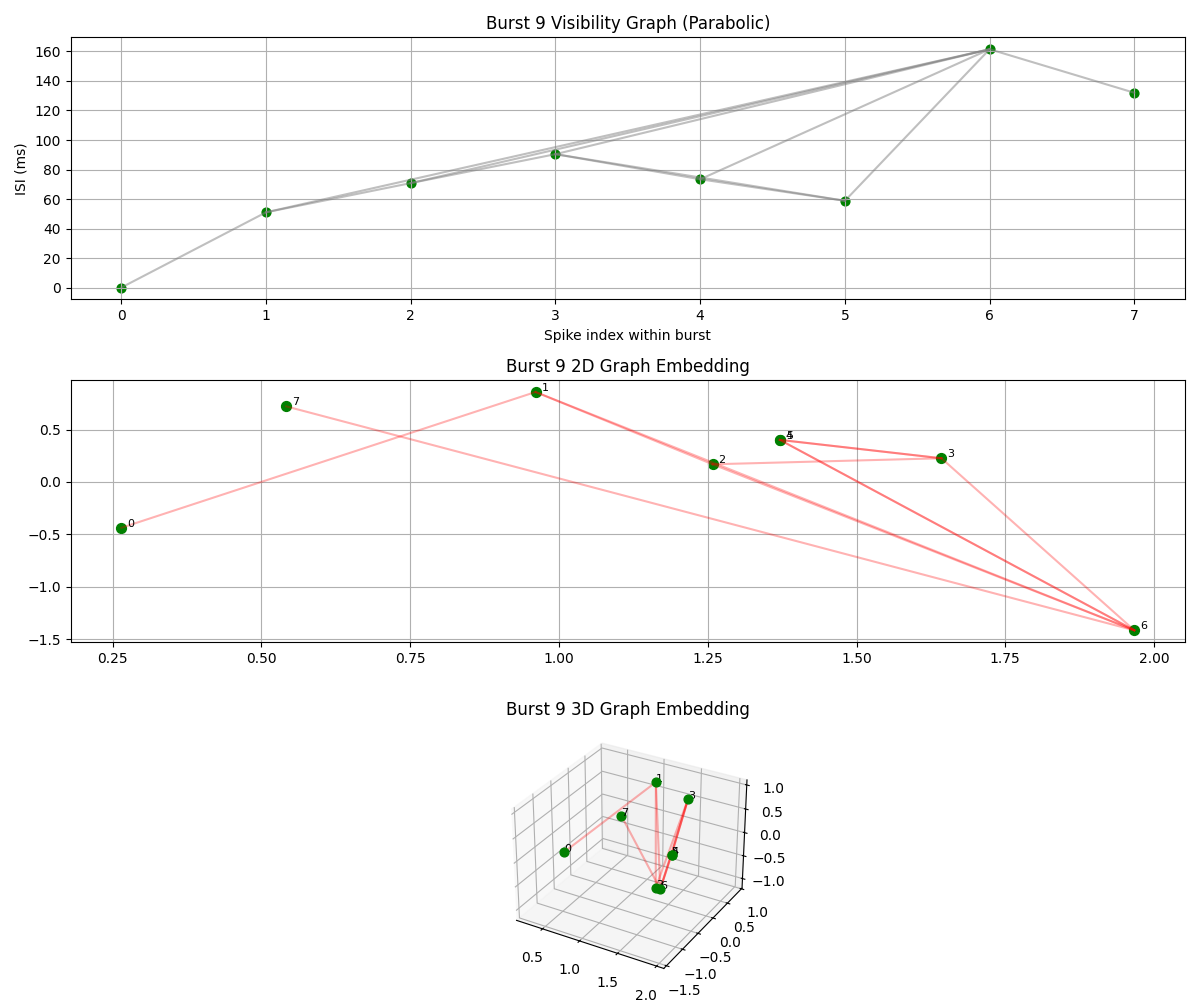

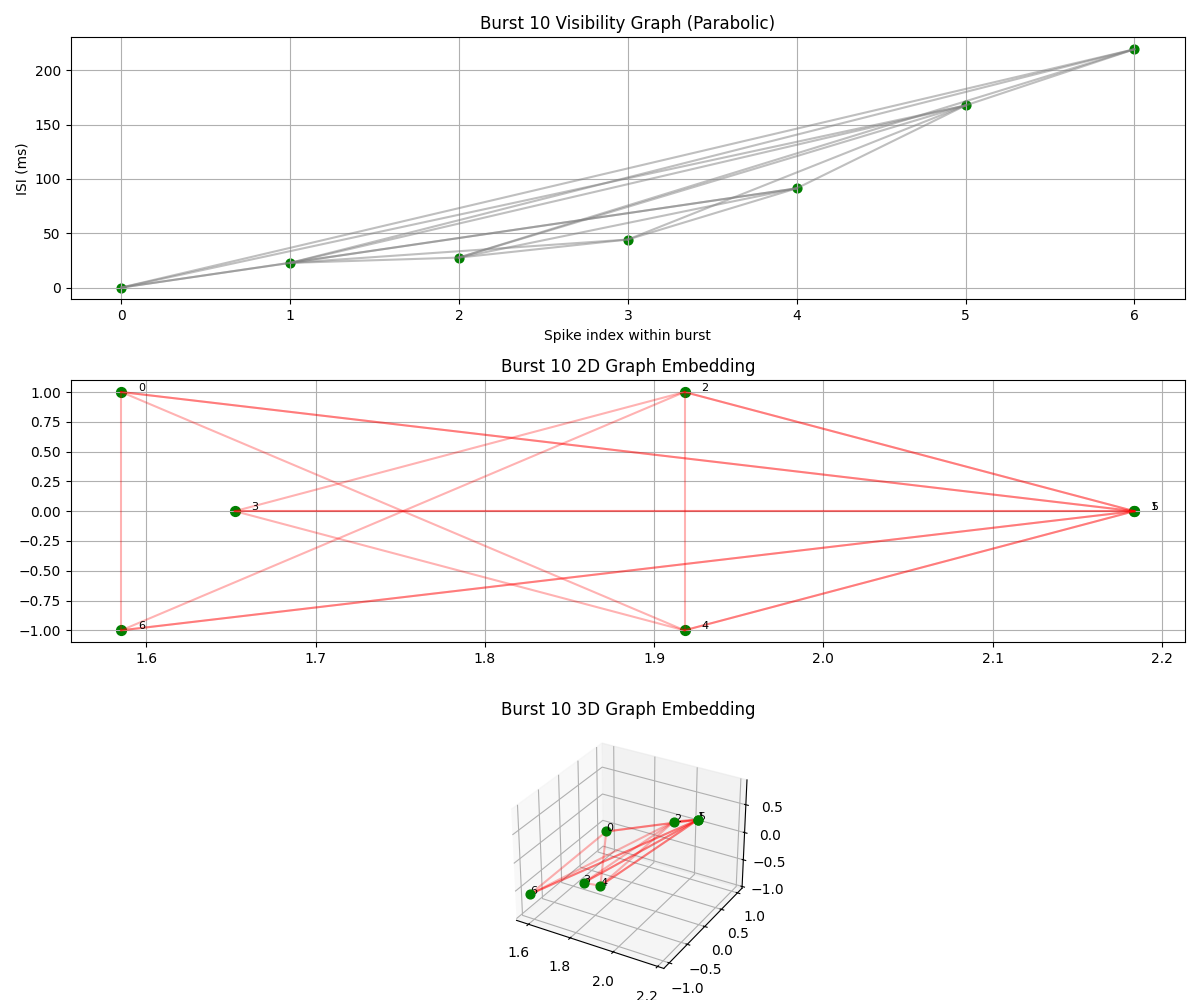

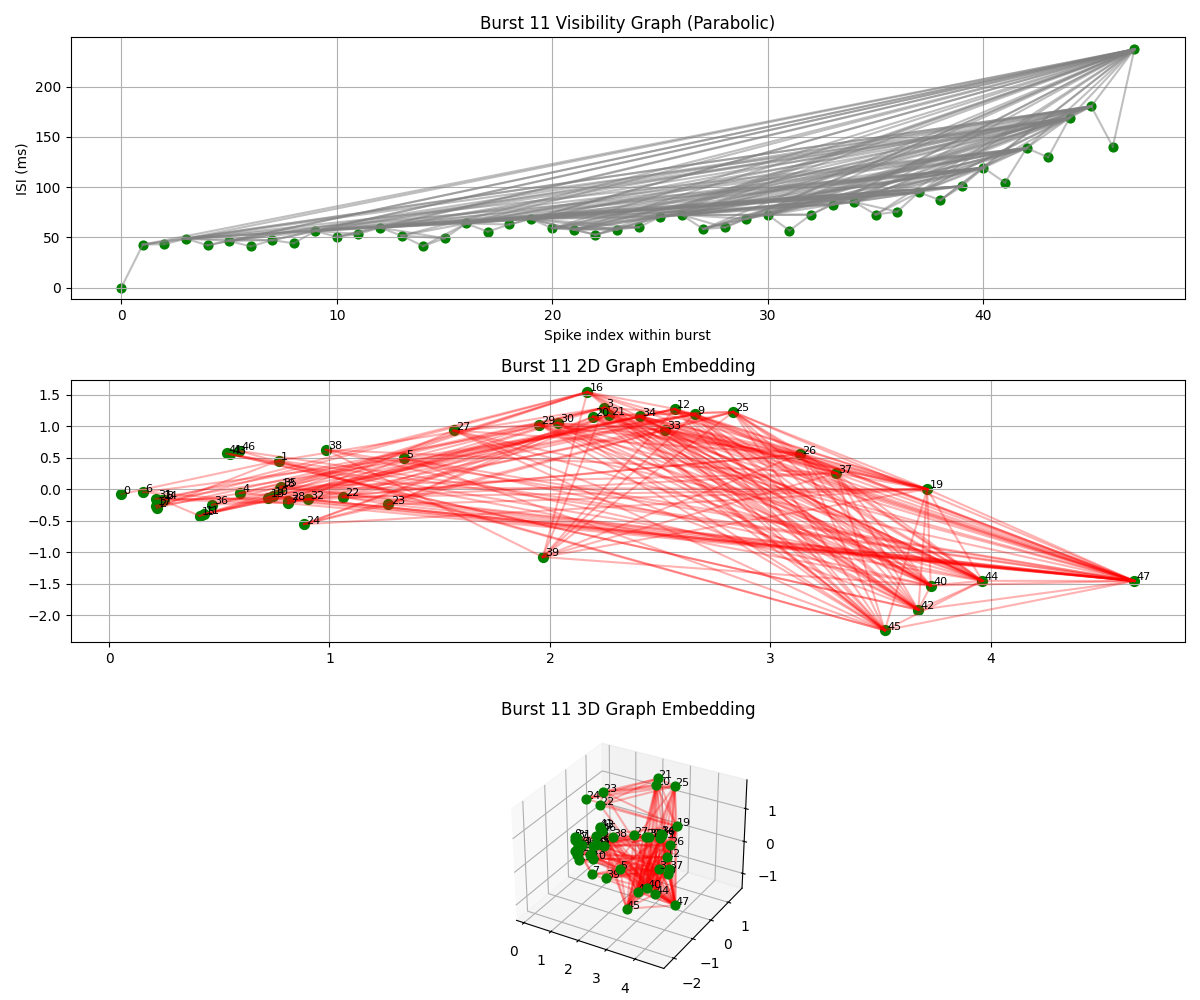

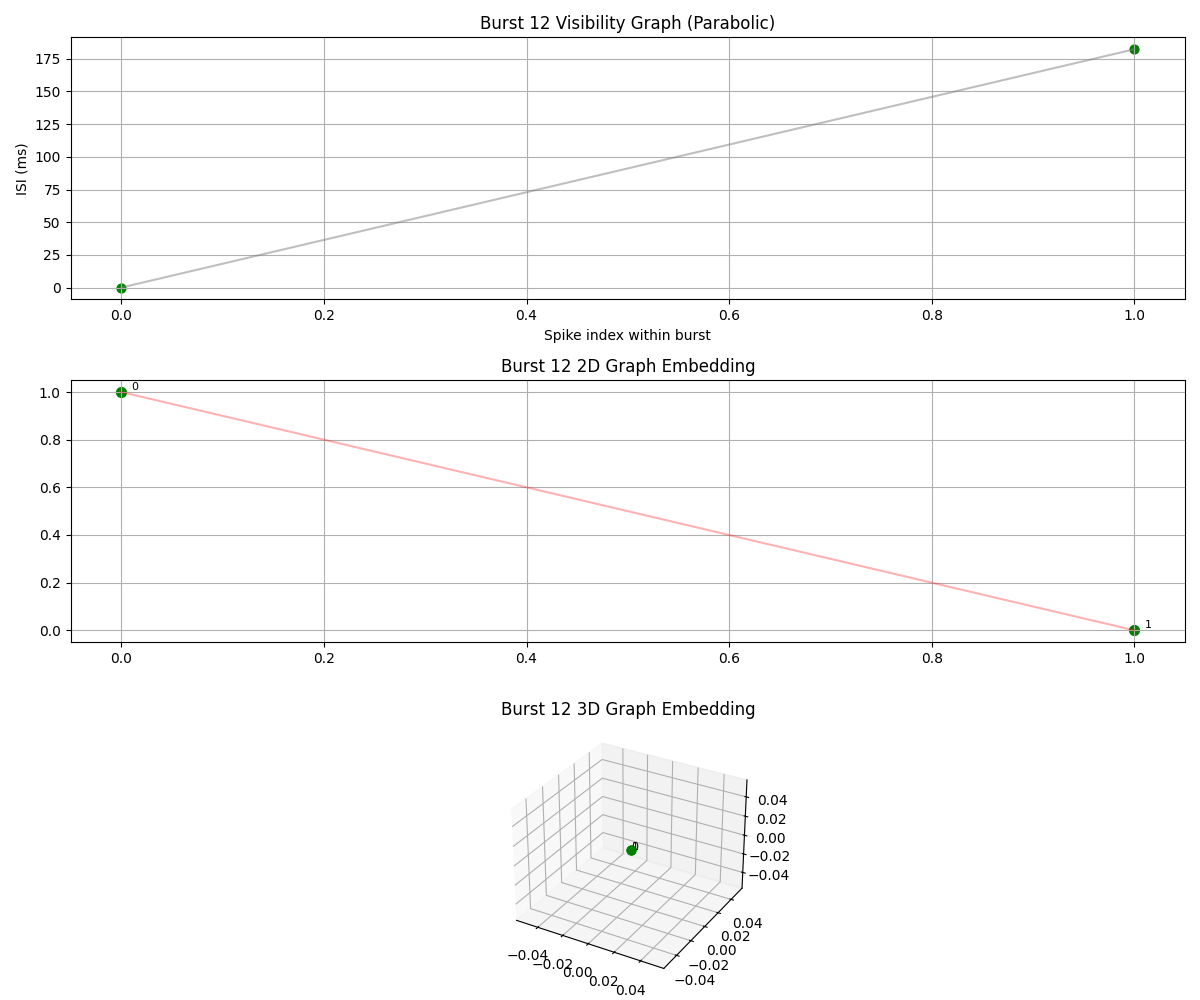

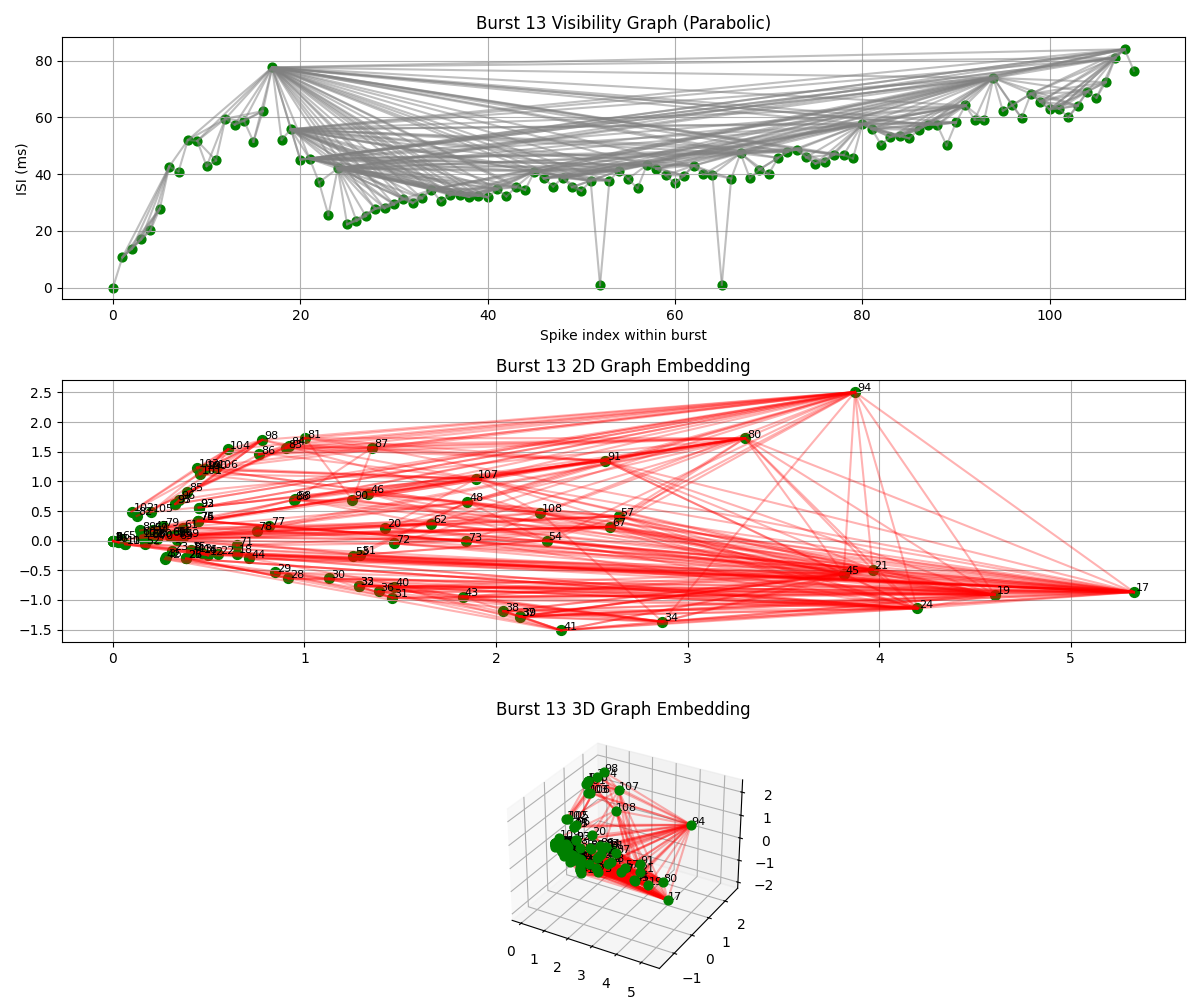

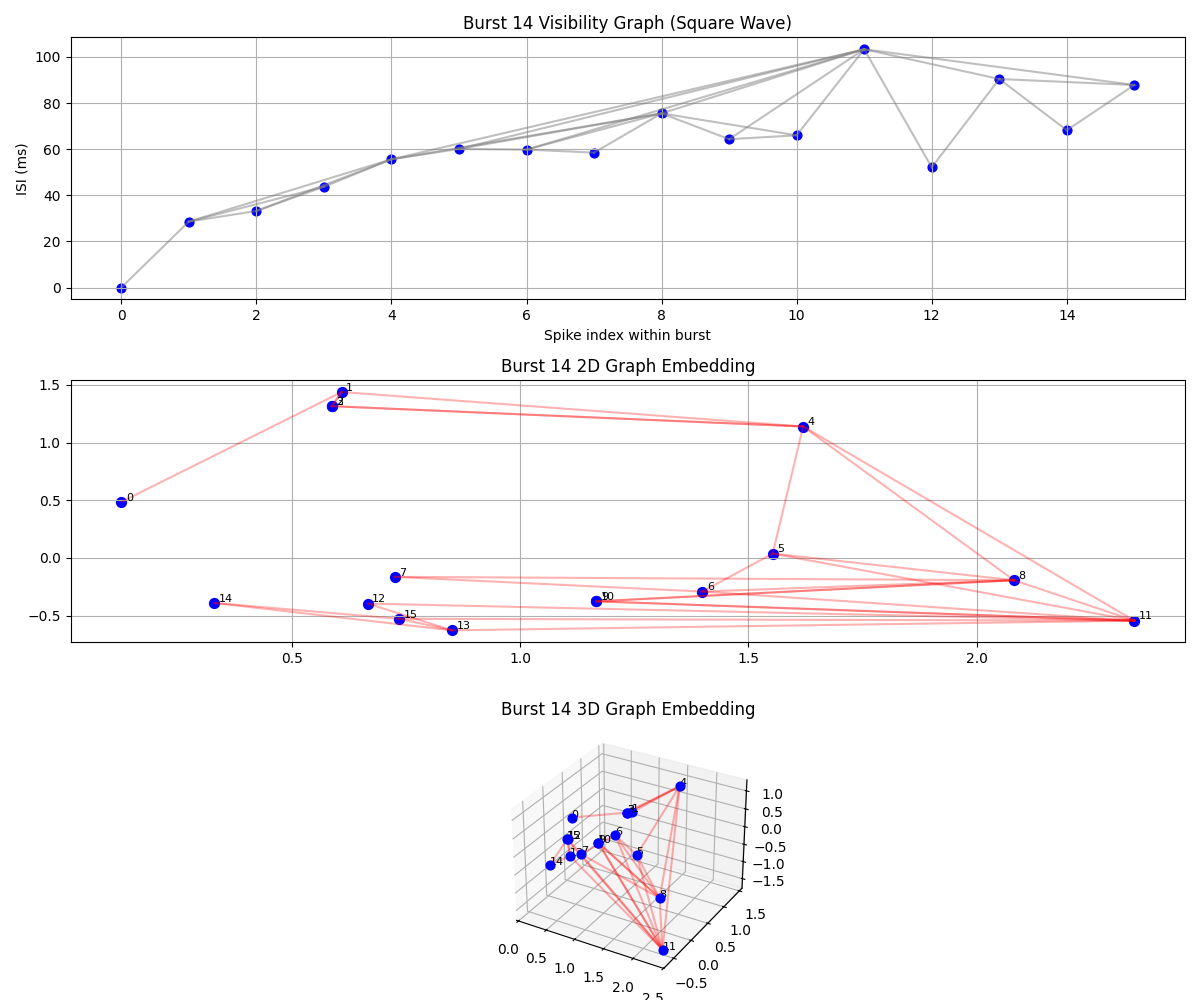

In [3]:

# BURST VISIBILITY GRAPH ANALYSIS  Deeply annotated version

# This script extends spike/burst detection by representing each burst
# as a "visibility graph" (a network where nodes are spikes and edges
# represent visual connectivity between them based on ISI values).
# Then it performs dimensionality reduction (embedding) of those graphs
# into 2D/3D spaces using Truncated SVD, and exports all results to CSV.



# 1. Import libraries

import pyabf                          # For reading .abf electrophysiology files
import numpy as np                    # Numerical operations (arrays, math, etc.)
import pandas as pd                   # Tabular data manipulation and CSV export
import matplotlib.pyplot as plt       # Visualization
import networkx as nx                 # Graph creation and analysis
from scipy.signal import find_peaks   # Spike (peak) detection
from sklearn.decomposition import TruncatedSVD  # Low-rank matrix embedding (2D/3D)
%matplotlib widget              


# 2. Load electrophysiological data

file_path = "bursting/cell89basal.abf"   # Path to the ABF recording file
abf = pyabf.ABF(file_path)               # Load the data using pyABF


# 3. Concatenate all sweeps into one continuous signal

# Each "sweep" in an ABF file is a separate voltage trace.
# We combine all of them into a single long array so that spike and burst
# detection operates over the whole recording.
signal = np.concatenate([abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)])

dt = 1.0 / abf.dataRate                 # Sampling interval in seconds
time = np.arange(len(signal)) * dt      # Time vector aligned with samples


# 4. Detect spikes (action potentials)

threshold = -35  # mV, detection threshold
# find_peaks returns indices of peaks in "signal" above threshold
spike_indices, _ = find_peaks(signal, height=threshold)
spike_times = time[spike_indices]  # Convert spike sample indices to seconds


# 5. Detect bursts (clusters of spikes close in time)
isi = np.diff(spike_times)         # Inter-spike intervals (in seconds)
burst_threshold = 0.3              # Maximum ISI to belong to the same burst (s)
bursts = []                        # List of bursts; each burst is a list of spike indices
current_burst = [0]                # Initialize with the first spike index

# Iterate over spikes and group those with short ISIs
for i in range(1, len(spike_times)):
    if isi[i-1] < burst_threshold:
        # Spike is close enough to the previous one → same burst
        current_burst.append(i)
    else:
        # ISI too long → burst ends
        if len(current_burst) > 1:
            bursts.append(current_burst)  # Store valid burst (≥2 spikes)
        current_burst = [i]               # Start new burst
# After loop, check if the last burst should be added
if len(current_burst) > 1:
    bursts.append(current_burst)

print(f"{len(bursts)} bursts detected")


# 6. Compute intra-burst ISIs (in milliseconds)

# Create a vector same length as spike_times, each entry will hold
# the ISI between a spike and the previous one within the same burst.
isi_per_spike_burst = np.zeros(len(spike_times))
for burst in bursts:
    for i, idx in enumerate(burst):
        if i == 0:
            isi_per_spike_burst[idx] = 0  # First spike of burst has no previous spike
        else:
            isi_per_spike_burst[idx] = (spike_times[idx] - spike_times[burst[i-1]]) * 1000
            # Convert seconds → milliseconds for easier interpretation


# 7. Classify bursts based on waveform characteristics

square_wave_bursts, parabolic_bursts, other_bursts = [], [], []
burst_types = {}  # Dictionary mapping each burst (as tuple of spike indices) to a string label

for i, burst in enumerate(bursts):
    # Mask for the signal segment corresponding to this burst
    burst_mask = (time >= spike_times[burst[0]]) & (time <= spike_times[burst[-1]])
    burst_min = np.min(signal[burst_mask])  # Minimum voltage during the burst (mV)

    # Estimate baseline (mean voltage before and after burst)
    prev_mean = np.mean(signal[(time > spike_times[bursts[i-1][-1]]) & 
                               (time < spike_times[burst[0]])]) if i > 0 else np.nan
    next_mean = np.mean(signal[(time > spike_times[burst[-1]]) & 
                               (time < spike_times[bursts[i+1][0]])]) if i < len(bursts)-1 else np.nan
    inter_mean = np.nanmean([prev_mean, next_mean])  # Average baseline ignoring NaNs

    # Classify by comparing burst minimum to the baseline mean
    if burst_min > inter_mean:
        square_wave_bursts.append(burst)
        burst_types[tuple(burst)] = "Square Wave"  # Elevated depolarized bursts
    elif burst_min < inter_mean:
        parabolic_bursts.append(burst)
        burst_types[tuple(burst)] = "Parabolic"    # Bursts with a downward curvature
    else:
        other_bursts.append(burst)
        burst_types[tuple(burst)] = "Other"        # Unclear or intermediate cases


# 8. Save basic burst information to CSV

burst_list = []  # Collect rows for output table

# Add bursts chronologically, including classification type
for idx, burst in enumerate(bursts):
    burst_type = burst_types[tuple(burst)]
    start_time = spike_times[burst[0]]
    end_time = spike_times[burst[-1]]
    burst_list.append([idx+1, start_time, end_time, burst_type])

# Convert to DataFrame
df_bursts_all = pd.DataFrame(burst_list, columns=["Burst_Number", "Start_Time_s", "End_Time_s", "Type"])

# Save all bursts
df_bursts_all.to_csv("burst_basic_info_cell89_all_bursts.csv", index=False)

# Show the first 10 bursts as a preview
df_bursts_head10 = df_bursts_all.iloc[:10]
print(df_bursts_head10)


# 9. Visibility Graph Construction and Embeddings

# Each burst is represented as a "visibility graph", where:
# - Each node = a spike in the burst
# - Edges connect spikes that "see" each other when plotted as ISI vs spike index


# This is inspired by visibility graph theory, often used in nonlinear time series.

colors_map = {"Square Wave": "blue", "Parabolic": "green", "Other": "orange"}  # Color coding by type
nodes_list, edges_list = [], []  # To store graph information globally across bursts

for b_idx, burst in enumerate(bursts):
    burst_type = burst_types[tuple(burst)]   # Retrieve label for current burst
    x_peaks = np.arange(len(burst))          # Spike indices within the burst (0..N-1)
    y_peaks = isi_per_spike_burst[burst]     # ISI values (ms) corresponding to each spike

    # Initialize an empty graph
    G = nx.Graph()
    G.add_nodes_from(range(len(burst)))      # One node per spike

    # Build visibility graph
    for a in range(len(x_peaks)):
        for b in range(a+1, len(x_peaks)):
            visible = True
            # Check intermediate spikes between a and b
            for c in range(a+1, b):
                # Linear interpolation: expected y on the line between (a, y_a) and (b, y_b)
                y_line = y_peaks[b] + (y_peaks[a] - y_peaks[b]) * (x_peaks[b] - x_peaks[c]) / (x_peaks[b] - x_peaks[a])
                if y_peaks[c] >= y_line:
                    # Visibility is blocked by an intermediate spike
                    visible = False
                    break
            if visible:
                G.add_edge(a, b)  # Connect visible spikes
                edges_list.append([b_idx+1, burst_type, a, b])  # Save edge info globally


    # 10. Dimensionality reduction (embedding)

    # Convert the graph structure into a matrix (adjacency matrix)
    A = nx.to_numpy_array(G)

    # Define embedding dimensionality (avoid >N dimensions)
    n_dim = min(3, A.shape[0])

    # Apply Truncated SVD to reduce adjacency matrix into 2D and 3D coordinates
    embedding_2d = TruncatedSVD(n_components=2, random_state=42).fit_transform(A)
    embedding_3d = (TruncatedSVD(n_components=n_dim, random_state=42).fit_transform(A)
                    if n_dim >= 3 else np.zeros((len(burst), 3)))

    # Store all node-level information (2D and 3D coordinates + global spike index)
    for i in range(len(burst)):
        nodes_list.append([b_idx+1, burst_type, i,
                           embedding_2d[i,0], embedding_2d[i,1],
                           embedding_3d[i,0], embedding_3d[i,1], embedding_3d[i,2],
                           burst[i]])  # Global index of spike


    # 11. Plotting (only for first few bursts)

    if b_idx < 14:
        fig = plt.figure(figsize=(12,10))

        # (a) Visibility Graph: spikes and edges
        ax0 = fig.add_subplot(3,1,1)
        for u, v in G.edges():
            ax0.plot([x_peaks[u], x_peaks[v]], [y_peaks[u], y_peaks[v]], 'gray', alpha=0.5)
        ax0.scatter(x_peaks, y_peaks, color=colors_map[burst_type], s=40)
        ax0.set_title(f"Burst {b_idx+1} Visibility Graph ({burst_type})")
        ax0.set_xlabel("Spike index within burst")
        ax0.set_ylabel("ISI (ms)")
        ax0.grid(True)

        # (b) 2D embedding visualization
        ax1 = fig.add_subplot(3,1,2)
        for i in range(len(burst)):
            ax1.scatter(embedding_2d[i,0], embedding_2d[i,1], color=colors_map[burst_type], s=50)
            ax1.text(embedding_2d[i,0]+0.01, embedding_2d[i,1]+0.01, str(i), fontsize=8)
        for u, v in G.edges():
            ax1.plot([embedding_2d[u,0], embedding_2d[v,0]],
                     [embedding_2d[u,1], embedding_2d[v,1]], 'r-', alpha=0.3)
        ax1.set_title(f"Burst {b_idx+1} 2D Graph Embedding")
        ax1.grid(True)

        # (c) 3D embedding visualization
        if embedding_3d is not None:
            ax2 = fig.add_subplot(3,1,3, projection='3d')
            for i in range(len(burst)):
                ax2.scatter(embedding_3d[i,0], embedding_3d[i,1], embedding_3d[i,2],
                            color=colors_map[burst_type], s=40)
                ax2.text(embedding_3d[i,0], embedding_3d[i,1], embedding_3d[i,2],
                         str(i), fontsize=8)
            for u, v in G.edges():
                ax2.plot([embedding_3d[u,0], embedding_3d[v,0]],
                         [embedding_3d[u,1], embedding_3d[v,1]],
                         [embedding_3d[u,2], embedding_3d[v,2]], 'r-', alpha=0.3)
            ax2.set_title(f"Burst {b_idx+1} 3D Graph Embedding")

        plt.tight_layout()
        plt.show()


# 12. Save node and edge data to CSV

df_nodes = pd.DataFrame(nodes_list, columns=[
    "Burst_Number", "Type", "Node_ID",
    "X_2D", "Y_2D", "X_3D", "Y_3D", "Z_3D",
    "Spike_Global_Index"
])
df_edges = pd.DataFrame(edges_list, columns=[
    "Burst_Number", "Type", "Node1_ID", "Node2_ID"
])

df_nodes.to_csv("burst_nodes_all.csv", index=False)
df_edges.to_csv("burst_edges_all.csv", index=False)
